## Time Series Data Prep

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load time series data
pitching = pd.read_csv('mlb_pitching.csv')
pitching.head()

,Year,Tms,#P,PAge,R/G,ERA,G,GF,CG,SHO,...,WP,BF,WHIP,BAbip,H9,HR9,BB9,SO9,SO/W,E
0,1871,9,19,24.3,10.47,4.22,254,0.09,0.91,0.02,...,0.82,44.15,1.553,0.288,12.4,0.2,1.6,0.7,0.45,7.61
1,1872,11,21,21.2,9.26,3.65,366,0.11,0.89,0.03,...,0.55,43.52,1.439,0.288,12.2,0.1,0.7,0.7,1.01,7.50
2,1873,9,25,21.3,8.99,3.40,398,0.09,0.91,0.02,...,0.31,43.45,1.468,0.293,12.4,0.1,0.8,0.7,0.83,8.02
3,1874,8,17,24.7,7.48,2.19,464,0.05,0.95,0.03,...,0.27,41.69,1.310,0.277,11.3,0.1,0.5,0.8,1.50,8.14
4,1875,13,42,24.3,6.14,2.23,690,0.10,0.90,0.07,...,0.48,39.25,1.141,0.259,9.9,0.1,0.4,1.0,2.71,6.96


In [110]:
# Make sure the Year is in datetime format
pitching['Year'] = pd.to_datetime(pitching['Year'], format='%Y')
# If not sorted (it is here)
# pitching = pitching.sort_values(by = 'Year')
# And setting it as the index, then extracting the single feature we want to predict (and dropping an NAs from it)
strikeout = pitching[['Year', 'SO9']]
strikeout.set_index('Year', inplace = True)
strikeout = strikeout.dropna()
# There are no NA here, if there were, after dropping we could downsample:
# check out the .resample function from Pandas to see the options: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html
# strikeout = strikeout.resample('7YE').mean().reset_index(drop=False)
strikeout.head()

,SO9
Year,
1871-01-01,0.7
1872-01-01,0.7
1873-01-01,0.7
1874-01-01,0.8
1875-01-01,1.0


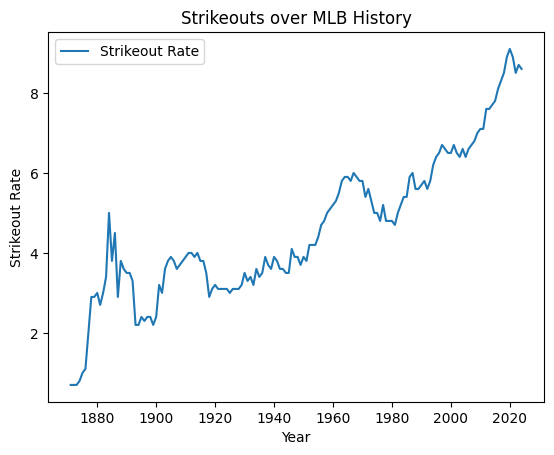

In [111]:
# visualize the time series
plt.plot(strikeout['SO9'], label='Strikeout Rate')
plt.xlabel('Year')
plt.ylabel('Strikeout Rate')
plt.legend()
plt.title('Strikeouts over MLB History')
plt.show();

In [112]:
data = pd.read_csv('nvidia_jan25.csv')
data['Date'] = pd.to_datetime(data['Date'], format='%m/%d/%Y')
data = data.sort_values(by = 'Date')
data.set_index('Date', inplace = True)
data = data.dropna()
data.head()

,Close
Date,
2025-01-02,138.31
2025-01-03,144.47
2025-01-06,149.43
2025-01-07,140.14
2025-01-08,140.11


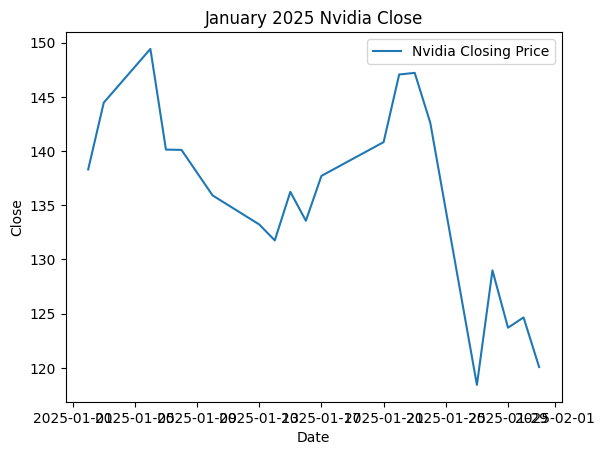

In [113]:
# visualize the time series
plt.plot(data['Close'], label='Nvidia Closing Price')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.title('January 2025 Nvidia Close')
plt.show();

### Lag and ACF Plots

In [114]:
# Creating "lag" features (to do the analysis manually)
# If we want to predict the SO9 next year given 1 lag (the previous year)
# pitching['Lag 1'] = pitching['SO9'].shift(1)
# If you want to explore different lags (say from 1 year up to 10 previous years)
for i in range(1, 11):
    strikeout[f'Lag {i}'] = strikeout['SO9'].shift(i)

# there will be some missing values for the early years, since we don't have (e.g.) 1870 to predict 1871
# this means (with a maximum lag of 10 to investigate) we lost years 1871-1880:
strikeout = strikeout.dropna()
strikeout.head()

,SO9,Lag 1,Lag 2,Lag 3,Lag 4,Lag 5,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10
Year,,,,,,,,,,,
1881-01-01,2.7,3.0,2.9,2.9,2.0,1.1,1.0,0.8,0.7,0.7,0.7
1882-01-01,3.0,2.7,3.0,2.9,2.9,2.0,1.1,1.0,0.8,0.7,0.7
1883-01-01,3.4,3.0,2.7,3.0,2.9,2.9,2.0,1.1,1.0,0.8,0.7
1884-01-01,5.0,3.4,3.0,2.7,3.0,2.9,2.9,2.0,1.1,1.0,0.8
1885-01-01,3.8,5.0,3.4,3.0,2.7,3.0,2.9,2.9,2.0,1.1,1.0


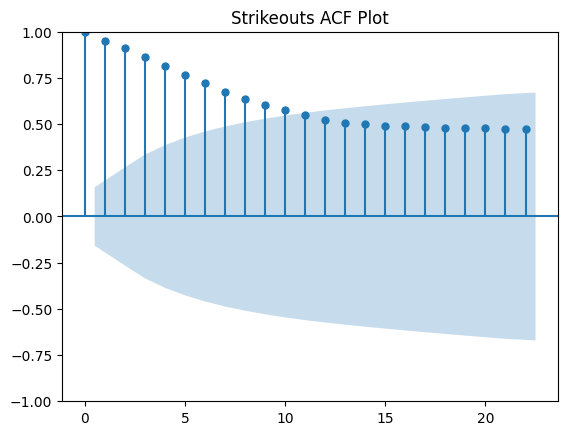

In [115]:
# Autocorrelation Function
# These are used to determine the appropriate lags for AR(p) or MA(q)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# use the original data
series = pitching['SO9']
plot_acf(series, title = 'Strikeouts ACF Plot')
plt.show();
# Geometric decay suggests an AR(p) model may be useful

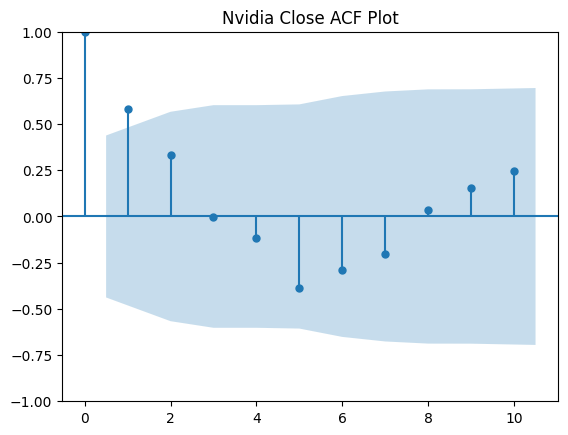

In [116]:
# meanwhile, for Nvidia stock, seems like the data may not be Autoregressive (ACF cuts off quickly)
series = data['Close']
plot_acf(series, title = 'Nvidia Close ACF Plot')
plt.show();

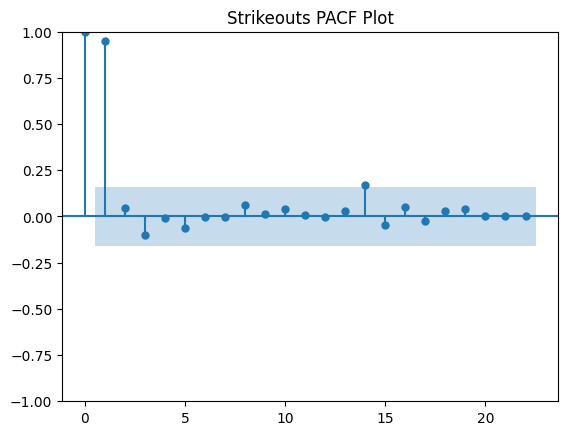

In [117]:
series = pitching['SO9']
plot_pacf(series, title = 'Strikeouts PACF Plot')
plt.show();
# Significant at lag 14 suggests AR(14) may be a good starting point

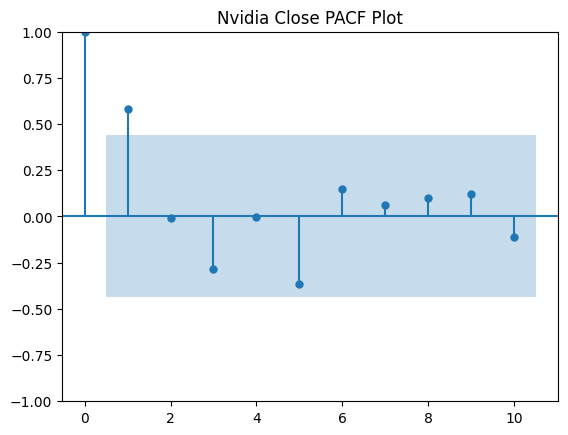

In [118]:
# meanwhile, for Nvidia stock, seems like the data may also not be Moving Average (PACF also cuts off quickly)
# Probably means these data just aren't very good for either model...
series = data['Close']
plot_pacf(series, title = 'Nvidia Close PACF Plot')
plt.show();

In [119]:
# Split into training and test sets; since we are looking at time series; we are NOT randomly splitting the data
# Take instead the first 80% for the training, then we'll see if the first 80% of MLB history can be used to predict the next 20%
train_size = int(.8 * len(strikeout))
train_data = strikeout[:train_size]
test_data = strikeout[train_size:]

# put the y feature (the current SO9) in arrays
y_train = np.array(train_data['SO9']).reshape(-1,1)
y_test = np.array(test_data['SO9']).reshape(-1,1)

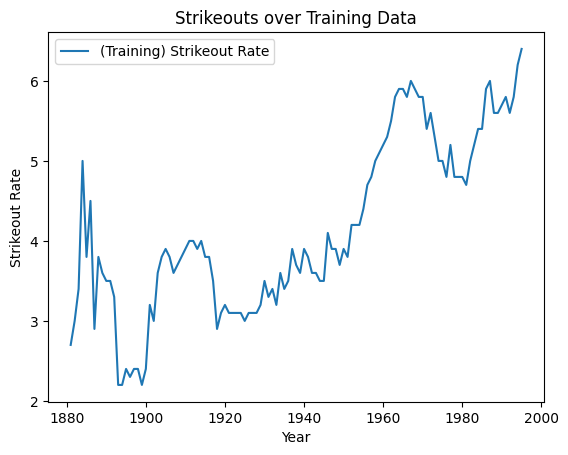

In [120]:
# visualize the time series
plt.plot(train_data['SO9'], label='(Training) Strikeout Rate')
plt.xlabel('Year')
plt.ylabel('Strikeout Rate')
plt.legend()
plt.title('Strikeouts over Training Data')
plt.show();

In [121]:
# We can confirm the values of the ACF using the correlation function
# For example, confirm that Lag 10 still has a large correlation
pitching['SO9'].corr(pitching['SO9'].shift(10))

np.float64(0.8089513136299691)

## Fitting AR(p) Models by Hand and using `statsmodels`

### By Hand

In [122]:
# However, let's start with a simple AR(1) model
X_train = np.array(train_data['Lag 1']).reshape(-1,1)
# If you want to add an intercept (since the default statsmodels package does so, and it can help make the model stable)
# X_train = np.hstack([np.array(train_data['Lag 1']).reshape(-1,1), np.ones(len(y_train)).reshape(-1,1)])
print(X_train.shape)
print(y_train.shape)

(115, 1)
(115, 1)


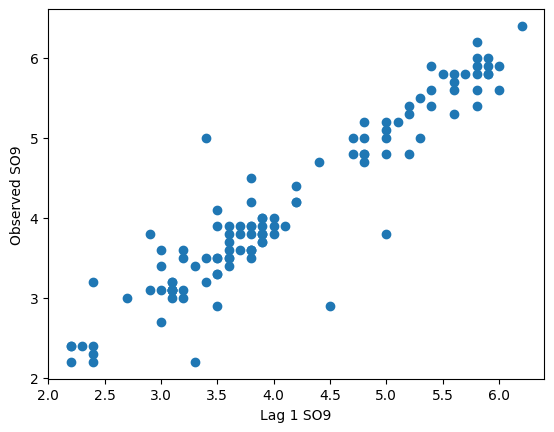

In [123]:
# we already know there should be a correlation at lag 1, let's confirm with a plot
# should mean that AR(1) is not too bad, given the training data
plt.scatter(x = X_train, y = y_train)
plt.xlabel('Lag 1 SO9')
plt.ylabel('Observed SO9')
plt.show();

In [124]:
# Fit the model using OLS:
w = np.dot(np.linalg.inv(np.dot(X_train.T, X_train)), np.dot(X_train.T, y_train))
w

array([[1.00410844]])

In [125]:
# Predictions
# Note; we assume we don't know anything except the previous year, so we iteratively use the predictions
y_pred = []
start = X_train[len(X_train)-1].reshape(-1,1)
for i in range(len(y_test)):
    y_pred.append(w.T.dot(start).flatten()[0])
    start = y_pred[i].reshape(-1,1) # without intercept
    # start = np.vstack([y_pred[i].flatten(), 1]) # with intercept
# This will probably result in not very good predictions...

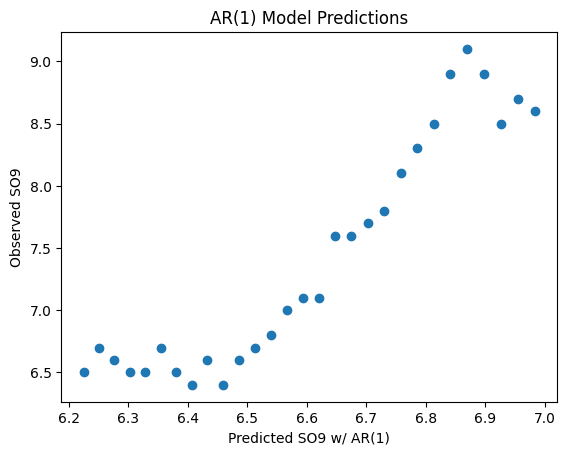

In [126]:
# observed versus predicted (one way)
plt.scatter(x = y_pred, y = y_test)
plt.xlabel('Predicted SO9 w/ AR(1)')
plt.ylabel('Observed SO9')
plt.title('AR(1) Model Predictions')
plt.show();

In [127]:
# observed versus predicted (another way, over time)
# put predictions into a data frame for plotting purposes
pred_data = pd.DataFrame({'Year': test_data.index, 'pred SO9': y_pred})
pred_data.set_index('Year', inplace = True)
pred_data.head()

,pred SO9
Year,
1996-01-01,6.225472
1997-01-01,6.251049
1998-01-01,6.276731
1999-01-01,6.302519
2000-01-01,6.328412


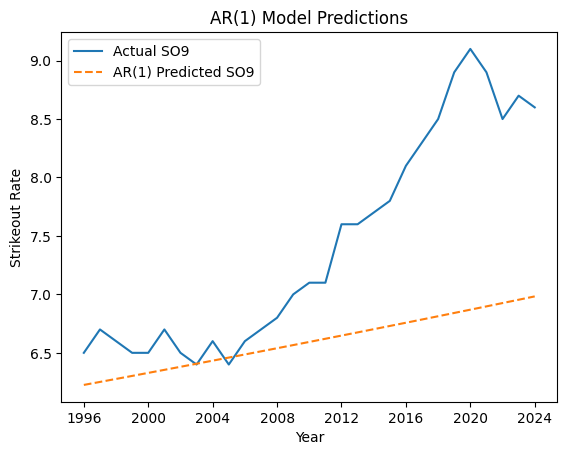

In [128]:
# make the plot
plt.plot(test_data['SO9'], label = 'Actual SO9')
plt.plot(pred_data['pred SO9'], label = 'AR(1) Predicted SO9', linestyle = '--')
plt.xlabel('Year')
plt.ylabel('Strikeout Rate')
plt.legend()
plt.title('AR(1) Model Predictions')
plt.show();

### `statsmodels`

In [129]:
# Using statsmodels AutoReg function
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import AutoReg

ar_model = AutoReg(y_train, lags=1, trend='n') # the default is to add an intercept (or, trend='c'), 
# using trend='n' is more in line with traditional AR(p) models, but may result in a nonstationary model
ar_results = ar_model.fit()

In [130]:
# get the parameters (should be very close to closed form)
# the difference is that AutoReg does not use OLS; it uses an MLE approach 
# (you should hopefully remember that from 4400, if not we may discuss it later; the short info is that MLE uses the data more efficiently)
# if the AutoReg function gives you very different parameters from the OLS, it is probably because n is not very large relative to p
ar_results.params

array([1.00456116])

In [131]:
# one benefit of this is that it is easy to check the roots of the model
# stability requires that the roots in modulus lie on or outside the unit circle (e.g. in AR(1), this should be greater than 1)
# but, if it's close to one, we can just handwave it for now...
ar_results.roots

array([0.99545955])

In [132]:
# the predictions
ar_pred = ar_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data2 = pd.DataFrame({'Year': test_data.index, 'pred SO9': ar_pred.flatten()})
pred_data2.set_index('Year', inplace = True)
pred_data2.head()

,pred SO9
Year,
1996-01-01,6.429191
1997-01-01,6.458516
1998-01-01,6.487974
1999-01-01,6.517567
2000-01-01,6.547295


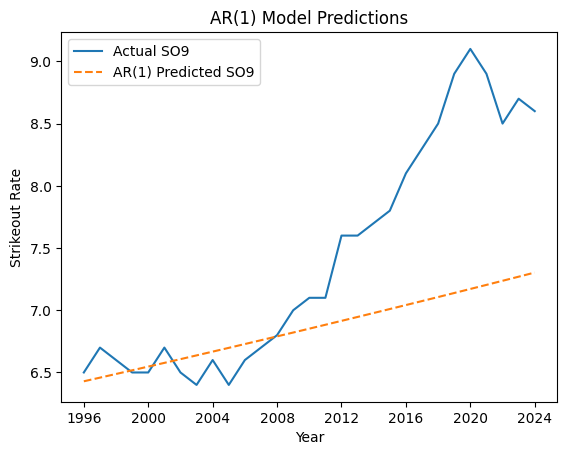

In [133]:
# make the plot
plt.plot(test_data['SO9'], label = 'Actual SO9')
plt.plot(pred_data2['pred SO9'], label = 'AR(1) Predicted SO9', linestyle = '--')
plt.xlabel('Year')
plt.ylabel('Strikeout Rate')
plt.legend()
plt.title('AR(1) Model Predictions')
plt.show();

In [134]:
# Probably we want to use a larger lag; say 14? (We identified that from the PACF earlier)
# Could do it manually, but we just confirmed that we know how AutoReg works, so...
ar_model = AutoReg(y_train, lags=14, trend='n')
ar_results = ar_model.fit()

In [135]:
# can get all the important info in a single function call
# to ensure stability, make sure all the Modulus values are > 1
ar_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                      y   No. Observations:                  115
Model:                    AutoReg(14)   Log Likelihood                  10.851
Method:               Conditional MLE   S.D. of innovations              0.217
Date:                Wed, 11 Feb 2026   AIC                              8.298
Time:                        10:12:20   BIC                             47.525
Sample:                            14   HQIC                            24.178
                                  115                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
y.L1           0.8931      0.100      8.911      0.000       0.697       1.089
y.L2           0.1511      0.129      1.174      0.240      -0.101       0.403
y.L3           0.0468      0.127      0.368      0.713      -0.202       0.296
y.L4          -0.0663      0.128     -0.518      0.605      -0.317       0.185
y.L5           0.0372      0.128      0.290      0.772      -0.215       0.289
y.L6          -0.0159      0.128     -0.124      0.902      -0.267       0.236
y.L7          -0.0200      0.122     -0.164      0.870      -0.260       0.220
y.L8          -0.1913      0.109     -1.753      0.080      -0.405       0.023
y.L9           0.1589      0.109      1.463      0.143      -0.054       0.372
y.L10         -0.0233      0.109     -0.215      0.830      -0.236       0.190
y.L11         -0.0591      0.095     -0.620      0.535      -0.246       0.128
y.L12          0.0511      0.094      0.541      0.588      -0.134       0.236
y.L13          0.0341      0.081      0.419      0.675      -0.125       0.194
y.L14          0.0139      0.070      0.200      0.842      -0.123       0.151
                                    Roots                                     
==============================================================================
                   Real          Imaginary           Modulus         Frequency
------------------------------------------------------------------------------
AR.1             0.9919           -0.0000j            0.9919           -0.0000
AR.2             1.0767           -0.3151j            1.1219           -0.0453
AR.3             1.0767           +0.3151j            1.1219            0.0453
AR.4             0.8141           -0.9913j            1.2828           -0.1406
AR.5             0.8141           +0.9913j            1.2828            0.1406
AR.6             0.3110           -1.2018j            1.2414           -0.2097
AR.7             0.3110           +1.2018j            1.2414            0.2097
AR.8            -0.4835           -1.0719j            1.1758           -0.3174
AR.9            -0.4835           +1.0719j            1.1758            0.3174
AR.10           -1.1008           -0.5346j            1.2237           -0.4280
AR.11           -1.1008           +0.5346j            1.2237            0.4280
AR.12           -1.7018           -0.0000j            1.7018           -0.5000
AR.13           -1.4856           -2.0546j            2.5354           -0.3496
AR.14           -1.4856           +2.0546j            2.5354            0.3496
------------------------------------------------------------------------------
"""

In [136]:
# the predictions
ar_pred = ar_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data3 = pd.DataFrame({'Year': test_data.index, 'pred SO9': ar_pred.flatten()})
pred_data3.set_index('Year', inplace = True)
pred_data3.head()

,pred SO9
Year,
1996-01-01,6.514030
1997-01-01,6.554706
1998-01-01,6.612342
1999-01-01,6.720302
2000-01-01,6.858634


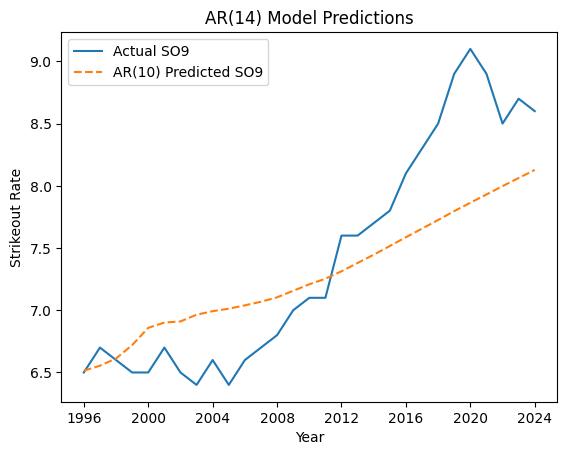

In [137]:
# make the plot
plt.plot(test_data['SO9'], label = 'Actual SO9')
plt.plot(pred_data3['pred SO9'], label = 'AR(10) Predicted SO9', linestyle = '--')
plt.xlabel('Year')
plt.ylabel('Strikeout Rate')
plt.legend()
plt.title('AR(14) Model Predictions')
plt.show();

In [138]:
# What about increasing the lag?
ar_model = AutoReg(y_train, lags=20, trend='n')
ar_results = ar_model.fit()

In [139]:
# the predictions
ar_pred = ar_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data3 = pd.DataFrame({'Year': test_data.index, 'pred SO9': ar_pred.flatten()})
pred_data3.set_index('Year', inplace = True)
pred_data3.head()

,pred SO9
Year,
1996-01-01,6.502344
1997-01-01,6.526391
1998-01-01,6.384514
1999-01-01,6.348875
2000-01-01,6.385698


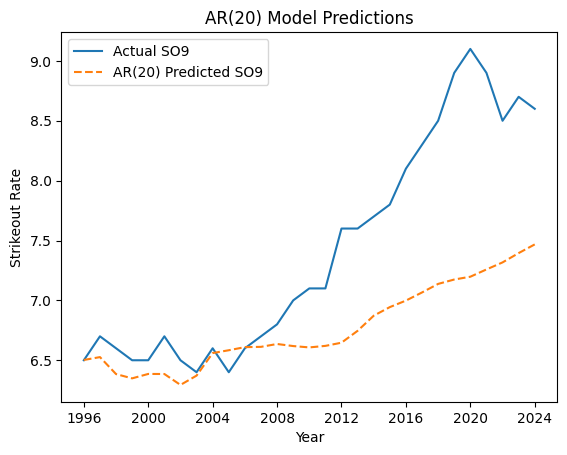

In [140]:
# make the plot
plt.plot(test_data['SO9'], label = 'Actual SO9')
plt.plot(pred_data3['pred SO9'], label = 'AR(20) Predicted SO9', linestyle = '--')
plt.xlabel('Year')
plt.ylabel('Strikeout Rate')
plt.legend()
plt.title('AR(20) Model Predictions')
plt.show();

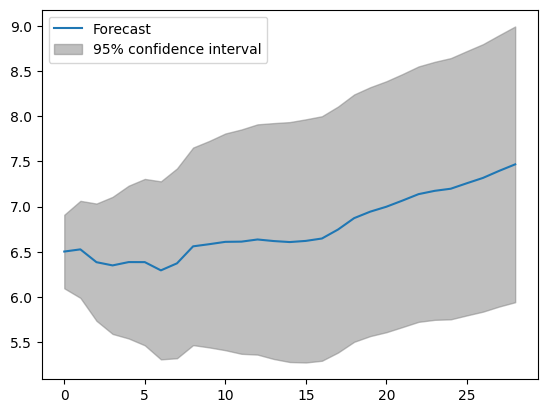

In [141]:
# this adds 95% confidence intervals around the predictions
# haven't figured out a way to overlay them on the truth yet though
ar_results.plot_predict(len(train_data), len(train_data) + len(test_data) - 1);

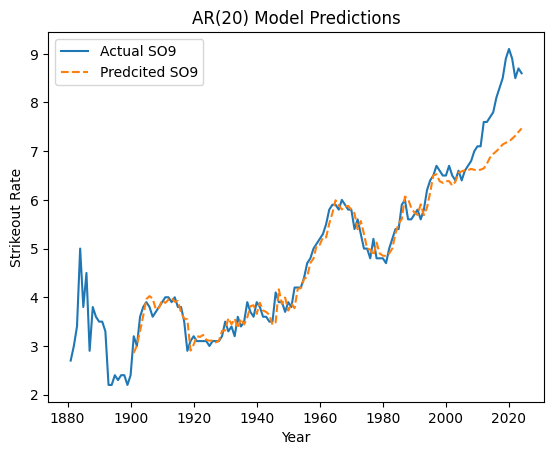

In [142]:
# Or, you could plot the entire history given predictions:
ar_pred_full = ar_results.predict(start=0, end=len(train_data) + len(test_data) - 1) # note we start at zero

plt.plot(strikeout['SO9'], label = 'Actual SO9')
plt.plot(strikeout.index, ar_pred_full, label = 'Predcited SO9', linestyle = '--')
plt.xlabel('Year')
plt.ylabel('Strikeout Rate')
plt.legend()
plt.title('AR(20) Model Predictions')
plt.show();

In [143]:
# We can also look at the MAE and RMSE, though these are only useful when comparing against other models
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

Mean Absolute Error: 0.82
Root Mean Squared Error: 1.08


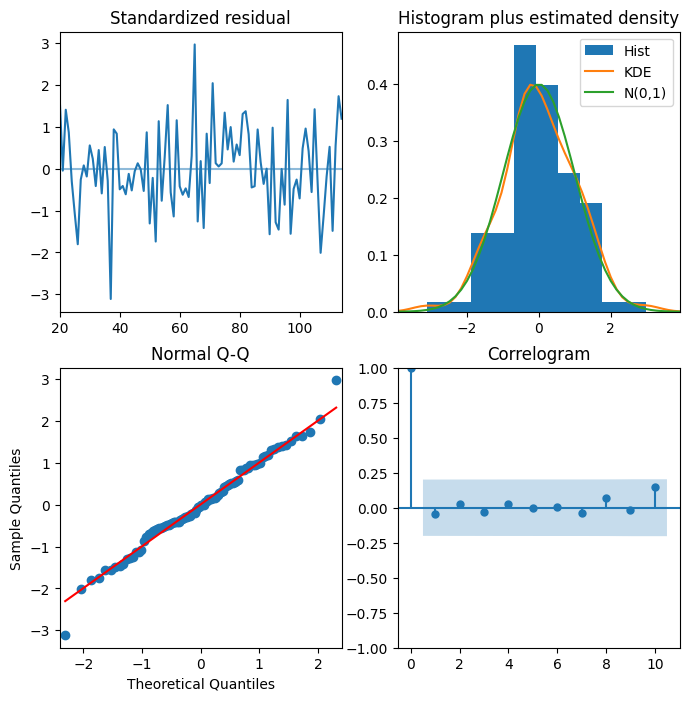

In [144]:
# since Time Series is a type of regression, we can check some diagnostic plots
# generally, you want to see random noise for the Standardized Resiudal, a normal histogram and QQ plot,
# and all lags > 0 to be within the control bounds of the correlogram
ar_results.plot_diagnostics(figsize=(8,8));

In [145]:
# This suggests that, given the information we had in the mid-90s, it would be very unlikely that anyone would have
# predicted the explosion of Strikeouts starting just 10 years later
# What about something that could possibly be better predicted?

### Practice (Airline Passenger Traffic Data)

In [146]:
# Here are some airline passenger traffic numbers over time
data = pd.read_csv('air_traffic.csv', header = None)
data.columns = ['Month','Passengers']
data['Month'] = pd.to_datetime(data['Month'], format='%Y-%m')
data.set_index('Month', inplace = True)
data = data.dropna()
data.head()

,Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


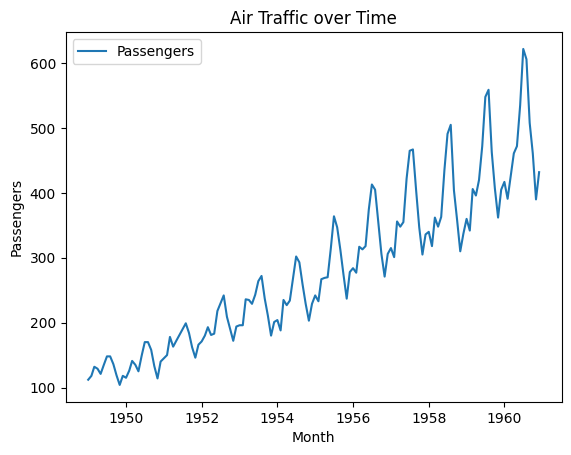

In [147]:
# visualize the time series
plt.plot(data['Passengers'], label='Passengers')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.title('Air Traffic over Time')
plt.show();

In [148]:
train_size = 120 # first 120 months
train_data = data[:train_size]
test_data = data[train_size:]

# put the y feature in arrays
y_train = np.array(train_data['Passengers']).reshape(-1,1)
y_test = np.array(test_data['Passengers']).reshape(-1,1)

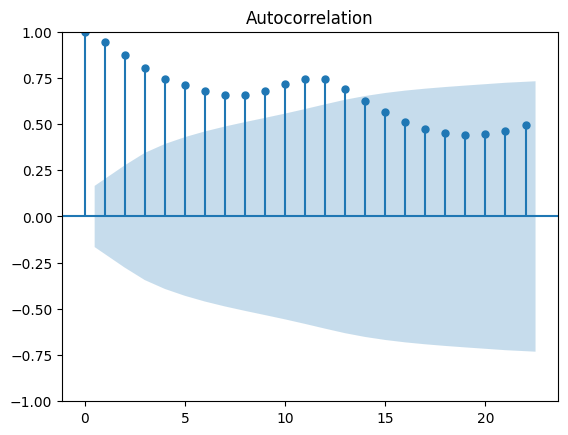

In [149]:
plot_acf(data['Passengers'])
plt.show();

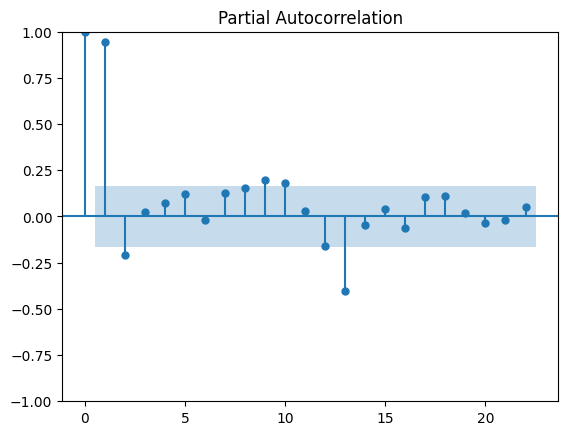

In [150]:
# suggests AR(13) may be best...
plot_pacf(data['Passengers'])
plt.show();

In [151]:
ar_model = AutoReg(y_train, lags=1, trend='n') # the default is to add an intercept (or, trend='c'), 
# using trend='n' is more in line with traditional AR(p) models, but may result in a nonstationary model
ar_results = ar_model.fit()

In [152]:
ar_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                      y   No. Observations:                  120
Model:                     AutoReg(1)   Log Likelihood                -572.739
Method:               Conditional MLE   S.D. of innovations             29.785
Date:                Wed, 11 Feb 2026   AIC                           1149.477
Time:                        10:12:22   BIC                           1155.035
Sample:                             1   HQIC                          1151.734
                                  120                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
y.L1           1.0028      0.010     97.779      0.000       0.983       1.023
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            0.9972           +0.0000j            0.9972            0.0000
-----------------------------------------------------------------------------
"""

In [153]:
# the predictions
ar_pred = ar_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data = pd.DataFrame({'Month': test_data.index, 'pred Passengers': ar_pred.flatten()})
pred_data.set_index('Month', inplace = True)
pred_data.head()

,pred Passengers
Month,
1959-04-01,407.122970
1959-05-01,408.249046
1959-06-01,409.378237
1959-07-01,410.510551
1959-08-01,411.645997


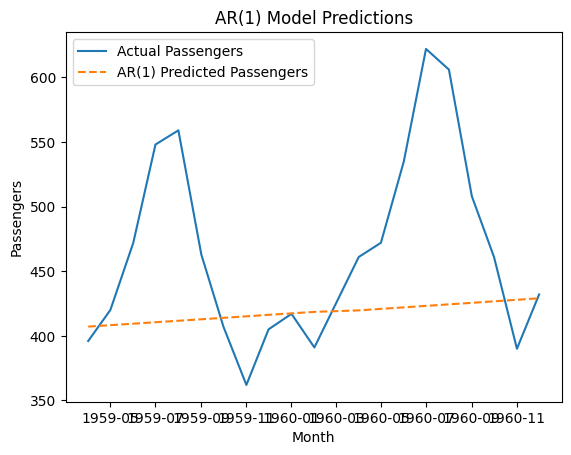

In [154]:
# make the plot
plt.plot(test_data['Passengers'], label = 'Actual Passengers')
plt.plot(pred_data['pred Passengers'], label = 'AR(1) Predicted Passengers', linestyle = '--')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.title('AR(1) Model Predictions')
plt.show();

In [155]:
# As we can see, it captures the general trend reasonably well, given where we left off
# But what about something like AR(13)?
ar_model = AutoReg(y_train, lags=13, trend='n') # the default is to add an intercept (or, trend='c'), 
# using trend='n' is more in line with traditional AR(p) models, but may result in a nonstationary model
ar_results = ar_model.fit()

In [156]:
ar_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                      y   No. Observations:                  120
Model:                    AutoReg(13)   Log Likelihood                -436.711
Method:               Conditional MLE   S.D. of innovations             14.332
Date:                Wed, 11 Feb 2026   AIC                            901.422
Time:                        10:12:23   BIC                            938.842
Sample:                            13   HQIC                           916.592
                                  120                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
y.L1           0.8114      0.085      9.568      0.000       0.645       0.978
y.L2          -0.2262      0.103     -2.206      0.027      -0.427      -0.025
y.L3           0.2953      0.102      2.900      0.004       0.096       0.495
y.L4          -0.3799      0.107     -3.561      0.000      -0.589      -0.171
y.L5           0.3808      0.115      3.319      0.001       0.156       0.606
y.L6          -0.3093      0.122     -2.538      0.011      -0.548      -0.070
y.L7           0.2447      0.130      1.885      0.059      -0.010       0.499
y.L8          -0.1944      0.137     -1.423      0.155      -0.462       0.073
y.L9           0.0987      0.134      0.736      0.462      -0.164       0.362
y.L10         -0.0445      0.128     -0.347      0.729      -0.296       0.207
y.L11          0.2614      0.123      2.118      0.034       0.020       0.503
y.L12          0.6600      0.122      5.411      0.000       0.421       0.899
y.L13         -0.5645      0.099     -5.677      0.000      -0.759      -0.370
                                    Roots                                     
==============================================================================
                   Real          Imaginary           Modulus         Frequency
------------------------------------------------------------------------------
AR.1            -0.8508           -0.5319j            1.0034           -0.4111
AR.2            -0.8508           +0.5319j            1.0034            0.4111
AR.3            -1.1679           -0.0000j            1.1679           -0.5000
AR.4            -0.5290           -0.8708j            1.0189           -0.3369
AR.5            -0.5290           +0.8708j            1.0189            0.3369
AR.6            -0.0216           -1.0147j            1.0149           -0.2534
AR.7            -0.0216           +1.0147j            1.0149            0.2534
AR.8             0.4865           -0.8670j            0.9941           -0.1686
AR.9             0.4865           +0.8670j            0.9941            0.1686
AR.10            0.8558           -0.4998j            0.9910           -0.0841
AR.11            0.8558           +0.4998j            0.9910            0.0841
AR.12            0.9910           -0.0000j            0.9910           -0.0000
AR.13            1.4646           -0.0000j            1.4646           -0.0000
------------------------------------------------------------------------------
"""

In [157]:
# the predictions
ar_pred = ar_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data = pd.DataFrame({'Month': test_data.index, 'pred Passengers': ar_pred.flatten()})
pred_data.set_index('Month', inplace = True)
pred_data.head()

,pred Passengers
Month,
1959-04-01,387.372865
1959-05-01,413.307189
1959-06-01,504.564659
1959-07-01,545.117715
1959-08-01,550.821620


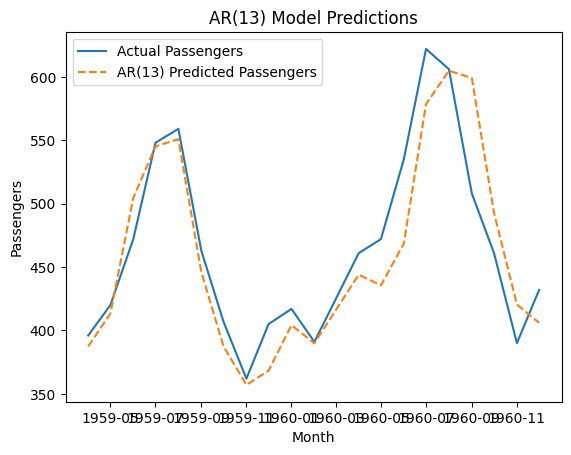

In [158]:
# make the plot
plt.plot(test_data['Passengers'], label = 'Actual Passengers')
plt.plot(pred_data['pred Passengers'], label = 'AR(13) Predicted Passengers', linestyle = '--')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.title('AR(13) Model Predictions')
plt.show();

In [159]:
# Pretty good! Suggests that from 1949-1961, airline travel followed a pretty consistent pattern!

## Fitting MA(q) Models using `statsmodels`

In [160]:
# The ARIMA function can fit both AR(p) and MA(q) models, as well as more complex ARMA(p,q) or ARIMA(p,d,q) models
# In the interest of time, we won't talk about combining them in class, but all you need to do to fit ARMA is to define the lag for both the
# Autoregressive Model (p) and the Moving Average Model (q) while setting the Integration filter (d=0)
from statsmodels.tsa.arima.model import ARIMA

# Regrabbing the pitching data
pitching = pd.read_csv('mlb_pitching.csv')
# Make sure the Year is in datetime format
pitching['Year'] = pd.to_datetime(pitching['Year'], format='%Y')
# If not sorted (it is here)
# pitching = pitching.sort_values(by = 'Year')
# And setting it as the index, then extracting the single feature we want to predict (and dropping an NAs from it)
strikeout = pitching[['Year', 'SO9']]
strikeout.set_index('Year', inplace = True)
strikeout = strikeout.dropna()
# There are no NA here, if there were, after dropping we could downsample:
# check out the .resample function from Pandas to see the options: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html
# strikeout = strikeout.resample('7YE').mean().reset_index(drop=False)
strikeout.head()

,SO9
Year,
1871-01-01,0.7
1872-01-01,0.7
1873-01-01,0.7
1874-01-01,0.8
1875-01-01,1.0


In [161]:
train_size = int(.8 * len(strikeout))
train_data = strikeout[:train_size]
test_data = strikeout[train_size:]

# put the y feature (the current SO9) in arrays
y_train = np.array(train_data['SO9']).reshape(-1,1)
y_test = np.array(test_data['SO9']).reshape(-1,1)

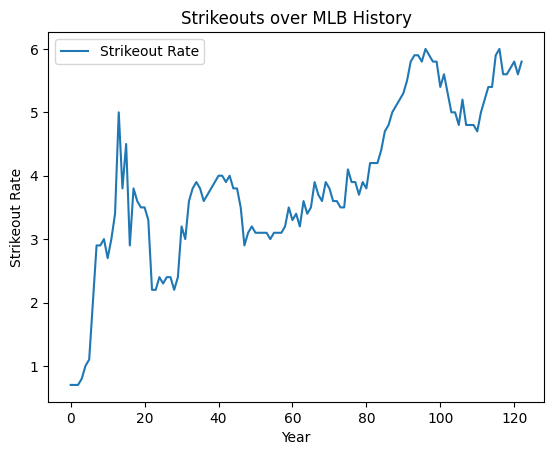

In [162]:
# visualize the time series
plt.plot(y_train, label='Strikeout Rate')
plt.xlabel('Year')
plt.ylabel('Strikeout Rate')
plt.legend()
plt.title('Strikeouts over MLB History')
plt.show();

In [163]:
# For AR(p), you would do ARIMA(series, order=(p, 0, 0), enforce_stationarity = False) #the last argument makes this match the AutoReg() function
# For MA(q), you would do ARIMA(series, order=(0, 0, q))
# For ARMA(p,q), it's ARIMA(series, order=(p, 0, q))
# And for ARIMA(p, d, q), it's ARIMA(series, order=(p,d,q)) # adding the integration filter helps account for non-stationarity
# though you should investigate a little bit more outside of class just what combining them entails before trusting
# here's the docs: https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html
ma_model = ARIMA(y_train, order=(0, 0, 1)) # here is the MA(1) model
ma_results = ma_model.fit()

#summary of the model
ma_results.summary()
# Interpretation: coef. of the constant is 3.8981 which works as the mean of the dataset 
# coefficient of the noise value ma.L1 is .7172, but the P>|z| tells us that this has a significant impact on the output
# (note, if we used the integration filter/differenced data, the constant is no longer interpretable as the mean/level of the series)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  123
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -151.021
Date:                Wed, 11 Feb 2026   AIC                            308.041
Time:                        10:12:23   BIC                            316.478
Sample:                             0   HQIC                           311.468
                                - 123                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8981      0.131     29.784      0.000       3.642       4.155
ma.L1          0.7172      0.050     14.345      0.000       0.619       0.815
sigma2         0.6783      0.091      7.466      0.000       0.500       0.856
===================================================================================
Ljung-Box (L1) (Q):                  37.95   Jarque-Bera (JB):                 3.91
Prob(Q):                              0.00   Prob(JB):                         0.14
Heteroskedasticity (H):               0.71   Skew:                            -0.44
Prob(H) (two-sided):                  0.28   Kurtosis:                         3.07
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [164]:
# getting the predictions works the same as in AR(p)
# but note that MA(q) models are even worse at long-term broadcasting
# and that everything after order q=1 is simply predicted at the mean
ma_pred = ma_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data = pd.DataFrame({'Year': test_data.index, 'pred SO9': ma_pred.flatten()})
pred_data.set_index('Year', inplace = True)
pred_data.head()

,pred SO9
Year,
1994-01-01,4.809616
1995-01-01,3.898053
1996-01-01,3.898053
1997-01-01,3.898053
1998-01-01,3.898053


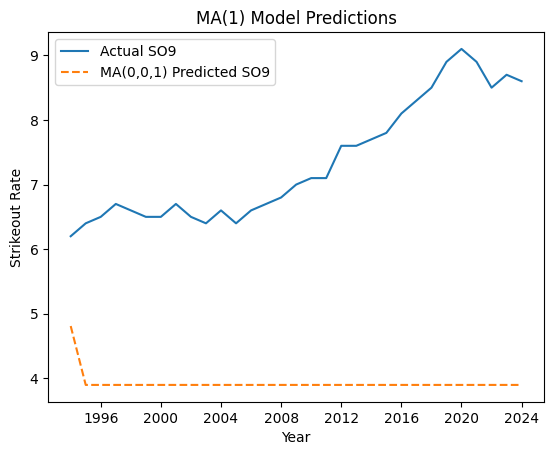

In [165]:
# make the plot
plt.plot(test_data['SO9'], label = 'Actual SO9')
plt.plot(pred_data['pred SO9'], label = 'MA(0,0,1) Predicted SO9', linestyle = '--')
plt.xlabel('Year')
plt.ylabel('Strikeout Rate')
plt.legend()
plt.title('MA(1) Model Predictions')
plt.show();

In [166]:
# what about increasing the order of the model?
# this will allow us to forecast q=10 lags out
ma_model = ARIMA(y_train, order=(0, 0, 10)) # here is the MA(10) model
ma_results = ma_model.fit()

# summary of the model
ma_results.summary()

C:\Users\eager\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  123
Model:                ARIMA(0, 0, 10)   Log Likelihood                 -43.128
Date:                Wed, 11 Feb 2026   AIC                            110.257
Time:                        10:12:24   BIC                            144.003
Sample:                             0   HQIC                           123.965
                                - 123                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8214      0.278     13.747      0.000       3.277       4.366
ma.L1          0.8133      0.100      8.127      0.000       0.617       1.009
ma.L2          1.1200      0.121      9.254      0.000       0.883       1.357
ma.L3          0.9628      0.122      7.913      0.000       0.724       1.201
ma.L4          0.9495      0.112      8.441      0.000       0.729       1.170
ma.L5          0.8579      0.136      6.293      0.000       0.591       1.125
ma.L6          1.1498      0.191      6.019      0.000       0.775       1.524
ma.L7          1.0381      0.196      5.295      0.000       0.654       1.422
ma.L8          0.8754      0.167      5.233      0.000       0.548       1.203
ma.L9          0.5878      0.122      4.837      0.000       0.350       0.826
ma.L10         0.2968      0.100      2.960      0.003       0.100       0.493
sigma2         0.1117      0.017      6.461      0.000       0.078       0.146
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):                23.41
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):               0.37   Skew:                            -0.67
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [167]:
# check the roots/modulus if you want, but the package will usually enforce them all > 1
abs(ma_results.maroots)

array([1.00890056, 1.00890056, 1.12271101, 1.12271101, 1.10236325,
       1.10236325, 1.23539826, 1.23539826, 1.18984707, 1.18984707])

In [168]:
# note that because this is an iterative algorithm (like gradient descent)
# we may get warnings about starting values and failure to converge!
# We can usually safely ignore the starting value warning. The Failure to converge is a bit more worrying...
import warnings
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found")

In [169]:
# Remember, AR and MA models will often do poorly with non-stationary series. 
# ARIMA will do differencing for you, and that can (sometimes) be enough to fix the issue

# adding an integration filter (moving to ARIMA) may help
# we may still fail to converge, you could try different methods, see the docs
ma_model_new = ARIMA(y_train, order=(0,1,10), trend='n')
ma_new_results = ma_model_new.fit()
ma_new_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  123
Model:                ARIMA(0, 1, 10)   Log Likelihood                 -33.846
Date:                Wed, 11 Feb 2026   AIC                             89.693
Time:                        10:12:25   BIC                            120.537
Sample:                             0   HQIC                           102.221
                                - 123                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2622      0.084     -3.108      0.002      -0.428      -0.097
ma.L2          0.2825      0.124      2.273      0.023       0.039       0.526
ma.L3         -0.1434      0.075     -1.915      0.056      -0.290       0.003
ma.L4          0.0932      0.133      0.701      0.483      -0.167       0.354
ma.L5          0.0616      0.115      0.536      0.592      -0.164       0.287
ma.L6          0.3382      0.084      4.040      0.000       0.174       0.502
ma.L7         -0.0127      0.098     -0.129      0.897      -0.206       0.180
ma.L8         -0.0443      0.112     -0.396      0.692      -0.263       0.175
ma.L9         -0.0467      0.091     -0.515      0.607      -0.225       0.131
ma.L10        -0.0578      0.112     -0.518      0.604      -0.277       0.161
sigma2         0.1009      0.011      8.827      0.000       0.078       0.123
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                50.27
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.24   Skew:                             0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [170]:
# check the roots/modulus if you want, but the package will usually enforce them all > 1
abs(ma_results.maroots)

array([1.00890056, 1.00890056, 1.12271101, 1.12271101, 1.10236325,
       1.10236325, 1.23539826, 1.23539826, 1.18984707, 1.18984707])

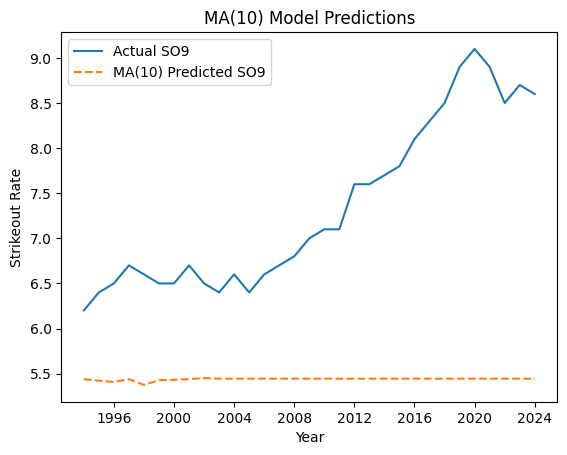

In [171]:
# even though we failed to converge, we can still see what the predictions look like:
ma_pred = ma_new_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data = pd.DataFrame({'Year': test_data.index, 'pred SO9': ma_pred.flatten()})
pred_data.set_index('Year', inplace = True)

plt.plot(test_data['SO9'], label = 'Actual SO9')
plt.plot(pred_data['pred SO9'], label = 'MA(10) Predicted SO9', linestyle = '--')
plt.xlabel('Year')
plt.ylabel('Strikeout Rate')
plt.legend()
plt.title('MA(10) Model Predictions')
plt.show();

In [172]:
# Doesn't seem the MA(q) models are doing very well with our baseball data
# using the ACF and PACF plots would confirm that the data we've been modeling is more Autoregressive than Moving Average
# Recall, if the ACF cuts off quickly/PACF shows geometric decay -> MA(q) -> use ACF to determine q
# If the PACF cuts off quickly/ACF shows geometric decay -> AR(p) -> use PACF to determine p
# If both cut off quickly -> probably random noise :(
# If both show geometric decay -> ARMA(p,q)

# We previously thought that the Nvidia data may be more MA than AR... Try seeing if an MA(q) model works:

In [173]:
data = pd.read_csv('nvidia_jan25.csv')
data['Date'] = pd.to_datetime(data['Date'], format='%m/%d/%Y')
data = data.sort_values(by = 'Date')
data.set_index('Date', inplace = True)
data = data.dropna()
series = data['Close']

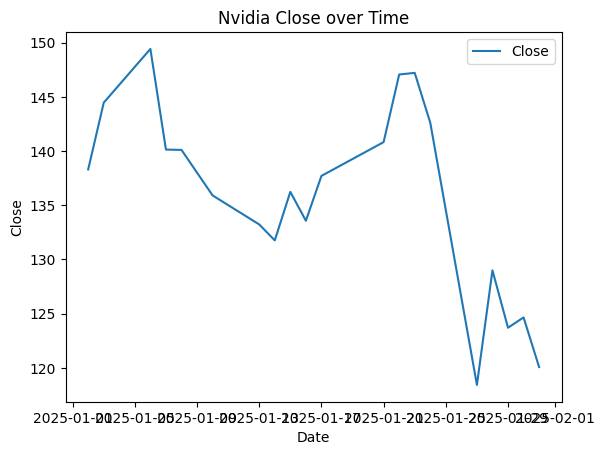

In [174]:
# visualize the time series
plt.plot(series, label='Close')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.title('Nvidia Close over Time')
plt.show();

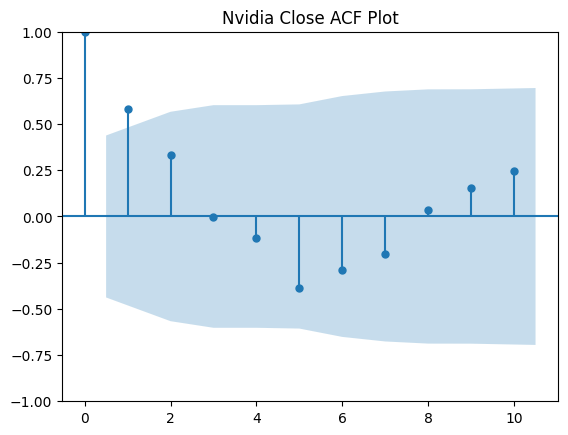

In [175]:
# Check the ACF
plot_acf(series, title = 'Nvidia Close ACF Plot')
plt.show();

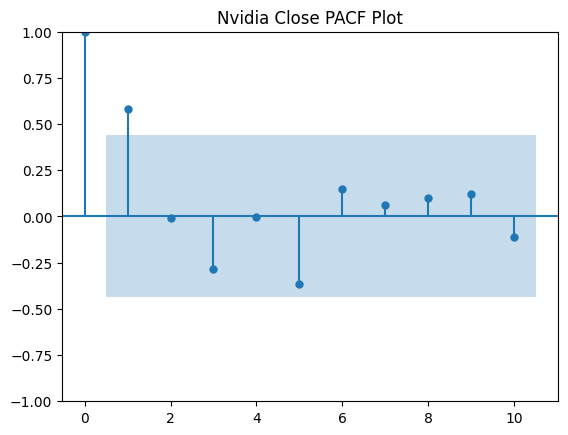

In [176]:
# check the Pacf plot
plot_pacf(series, title = 'Nvidia Close PACF Plot')
plt.show();

In [177]:
# hard to say because there's so little data; neither? little bit of both? Probably ARMA(p,q) will work better than either individually
# if we pretend it's MA(q) and say the ACF cuts off "quickly", probably that's an MA(1)

In [178]:
train_size = int(.5 * len(data))
train_data = data[:train_size]
test_data = data[train_size:]

# put the y feature in arrays
y_train = np.array(train_data['Close']).reshape(-1,1)
y_test = np.array(test_data['Close']).reshape(-1,1)

In [179]:
ma_model = ARIMA(y_train, order=(0, 0, 1)) # here is the MA(1) model (larger q may take longer to run)
ma_results = ma_model.fit(method_kwargs={'maxiter':300}) # setting maximum iterations to handle non convergence issues

#summary of the model
ma_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   10
Model:                 ARIMA(0, 0, 1)   Log Likelihood                 -29.043
Date:                Wed, 11 Feb 2026   AIC                             64.086
Time:                        10:12:26   BIC                             64.994
Sample:                             0   HQIC                            63.090
                                 - 10                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        138.0716      2.704     51.053      0.000     132.771     143.372
ma.L1          0.4887      0.504      0.969      0.332      -0.499       1.477
sigma2        18.9811     17.596      1.079      0.281     -15.506      53.468
===================================================================================
Ljung-Box (L1) (Q):                   0.60   Jarque-Bera (JB):                 1.02
Prob(Q):                              0.44   Prob(JB):                         0.60
Heteroskedasticity (H):               0.43   Skew:                             0.66
Prob(H) (two-sided):                  0.50   Kurtosis:                         2.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [180]:
# check the roots/modulus if you want, but the package will usually enforce them all > 1
abs(ma_results.maroots)

array([2.04638097])

In [181]:
# getting the predictions for test data
ma_pred = ma_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data = pd.DataFrame({'Date': test_data.index, 'pred Close': ma_pred.flatten()})
pred_data.set_index('Date', inplace = True)
pred_data.head()

,pred Close
Date,
2025-01-17,135.747513
2025-01-21,138.071565
2025-01-22,138.071565
2025-01-23,138.071565
2025-01-24,138.071565


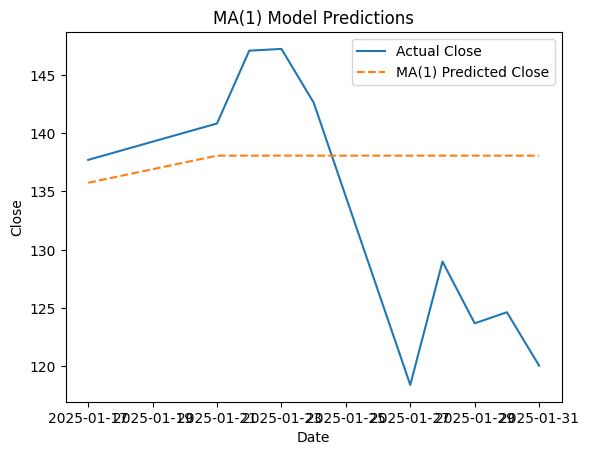

In [182]:
# make the plot
plt.plot(test_data['Close'], label = 'Actual Close')
plt.plot(pred_data['pred Close'], label = 'MA(1) Predicted Close', linestyle = '--')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.title('MA(1) Model Predictions')
plt.show();

In [183]:
# This is a tiny data set! Probably neither model is appropriate.